# Bernoulli and the Venturi effect, with the assumptions relaxed

Along a streamline:

$$p + \tfrac{1}{2}\rho v^2 + \gamma z = \text{constant}$$

which holds only for steady, inviscid, incompressible flow along a single streamline.

## Tasks:

1. Size a Venturi meter for water and get the flowrate from the pressure drop.

2. Relax inviscid assumption: put in a discharge coefficient and a permanent pressure loss.

3. Relax incompressible assumption: find the Mach number at which constant density stops being acceptable.

Work in SI throughout:

- Water at 20 °C: $\rho = 998\ \mathrm{kg/m^3}$, $p_v = 2.34\ \mathrm{kPa}$.

**Data.**
Let us consider the following conditions:
- Line $100 \mathrm{mm}$, throat $50 \mathrm{mm}$.

- The Ventuti meter is $0.60 \mathrm{m}$ long: contraction from $x = 0.15$ m, throat between $x = 0.20$ and $0.23$ m, diffuser back to full bore by $x = 0.45$ m.

- Working pressure drop $20 \mathrm{kPa}$; the sweeps run to $60 \mathrm{kPa}$.

In [40]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt

In [41]:
# Constants

rho_w = 998.0        # density of water at 20 C, kg/m^3
p_v   = 2.34e3       # vapour pressure of water at 20 C, Pa
p_atm = 101.325e3    # atmospheric pressure, Pa

rho_a = 1.20         # density of air at 20 C, kg/m^3
Gamma = 1.40         # ratio of specific heats, c_p/c_v, for air
c_a   = 343.0        # speed of sound in air at 20 C, m/s

## 1. The ideal Venturi

Conservation of mass through the duct gives $Q = A_1 v_1 = A_2 v_2$ (confined flows), and Bernoulli along the axis, with $z$ constant, gives

$$p_1 - p_2 = \tfrac{1}{2}\rho\left(v_2^2 - v_1^2\right)$$

This has 2 unknown velocities, but the Venturi meter gives only 1 number, $p_1 - p_2$. 

Continuity supplies the missing equation, $v_1 = (A_2/A_1)\,v_2 = \beta^2 v_2$ with $\beta = D_2/D_1$

We keep $v_2$:

$$p_1 - p_2 = \tfrac{1}{2}\rho\, v_2^2\left(1 - \beta^4\right) \qquad\Longrightarrow\qquad Q_{\rm ideal} = A_2\sqrt{\frac{2\,(p_1-p_2)}{\rho\,(1-\beta^4)}}$$

The fluid was already moving at section 1, so the pressure drop is less than the full dynamic pressure at the throat. 

For a tank, $\beta \to 0$, the factor disappears and we recover the free-jet result.

In [42]:
# Geometry in m. Munson's Example 3.11 uses D1 = 0.10 m and D2 = 0.06 m.
D1, D2 = 0.10, 0.05

# Areas
A1 = np.pi * D1**2 / 4
A2 = np.pi * D2**2 / 4

# Beta
beta = D2 / D1

print(f"A_1  = {A1*1e4:6.2f} cm^2")
print(f"A_2  = {A2*1e4:6.2f} cm^2")
print(f"beta = {beta:6.2f}")

A_1  =  78.54 cm^2
A_2  =  19.63 cm^2
beta =   0.50


In [43]:
# Ideal flowrate from the pressure drop, in m^3/s
Q_ideal = lambda dp, rho = rho_w: A2 * np.sqrt(2.0 * dp / (rho * (1.0 - beta**4)))

# From data (pressure drop/difference)
dp = 20.0e3          # Pa

Q = Q_ideal(dp)

print(f"dp  = {dp/1e3:6.1f} kPa")
print(f"Q   = {Q*1e3:6.2f} L/s")
print(f"v_1 = {Q/A1:6.2f} m/s")
print(f"v_2 = {Q/A2:6.2f} m/s")

dp  =   20.0 kPa
Q   =  12.84 L/s
v_1 =   1.63 m/s
v_2 =   6.54 m/s


In [44]:
# Diameter along the Venturi meter: inlet, convergent, throat, divergent, outlet, see data
x = np.linspace(0.0, 0.60, 400)                       # m

# Linear interpolation
D_x = np.interp(x, [0.00, 0.15, 0.20, 0.23, 0.45, 0.60], [D1,   D1,   D2,   D2,   D1,   D1])

# Area
A_x = np.pi * D_x**2 / 4

# Velocity and pressure along the axis
v_x = Q / A_x                                          # m/s
p_x = p_atm - 0.5 * rho_w * (v_x**2 - (Q/A1)**2)       # Pa

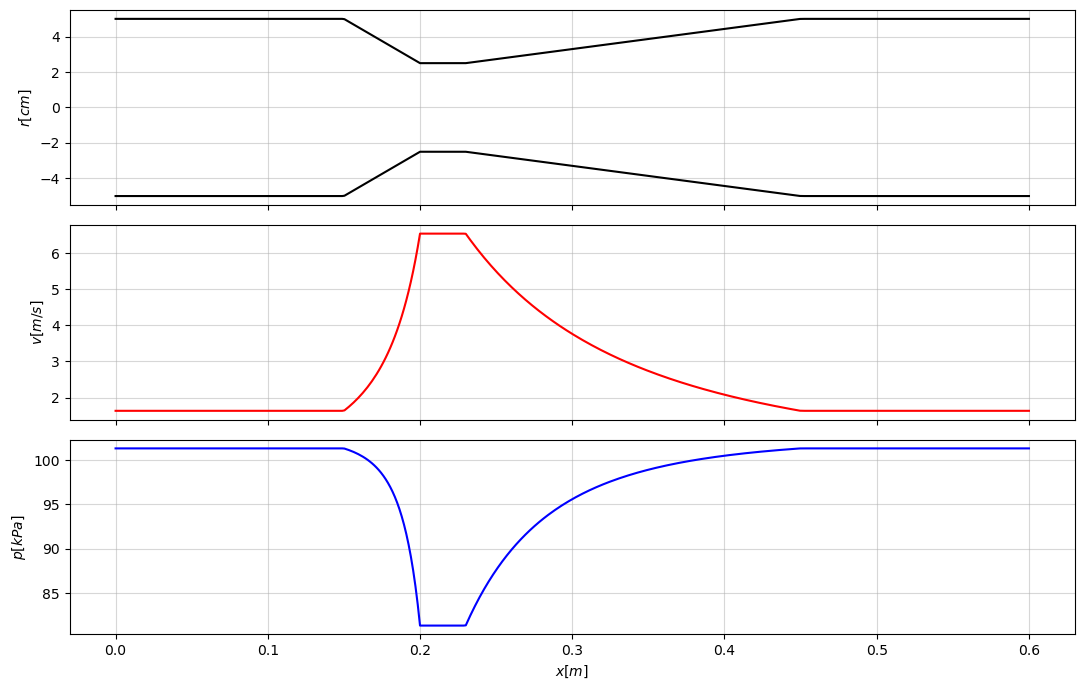

In [45]:
# Plotting
fig, axs = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axs[0].plot(x,  D_x/2*1e2, color="k")
axs[0].plot(x, -D_x/2*1e2, color="k")
axs[0].set_ylabel(r"$r [cm]$")

axs[1].plot(x, v_x, color="red")
axs[1].set_ylabel(r"$v [m/s]$")

axs[2].plot(x, p_x/1e3, color="blue") # to kPa
axs[2].set_ylabel(r"$p [kPa]$")
axs[2].set_xlabel(r"$x [m]$")

for ax in axs:
    ax.grid(alpha=0.5)

plt.tight_layout()

plt.show()

### Observations:

- The velocity is fixed by the area alone: continuity eq.

- Bernoulli eq. only converts it into a pressure.

- The pressure is lowest exactly where the velocity is highest, and the ideal equation returns it completely in the diffuser.

- Nothing in this calculation includes **viscosity**. That is the first assumption we will drop.

## 2. Relaxing inviscid assumption: the discharge coefficient

A real Venturi meter loses a little energy to friction, so it passes slightly less than the ideal flowrate for the same pressure drop.

The loss is collected into a discharge coefficient:

$$Q = C_d\,Q_{\rm ideal}$$

with $C_d \approx 0.98$ for a machined Venturi and $C_d \approx 0.61$ for a sharp orifice plate.

In [46]:
# Dictionary with discharge coefficients

Cds = {"ideal": 1.00, "Venturi": 0.98, "orifice plate": 0.61}

dps = np.linspace(0.0, 60e3, 300)      # Pa

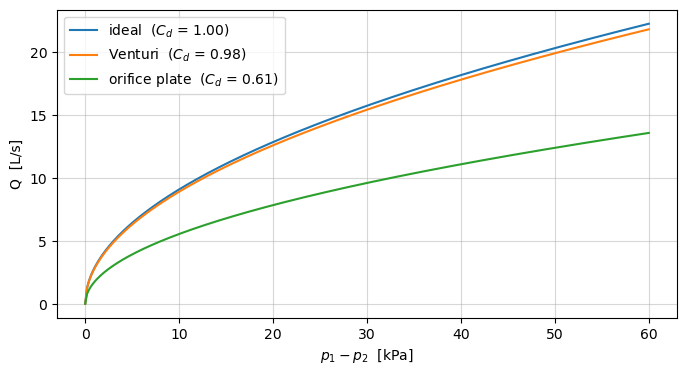

In [47]:
# Plotting
plt.figure(figsize=(8, 4))

for label, Cd in Cds.items():
    plt.plot(dps/1e3, Cd*Q_ideal(dps)*1e3, label=f"{label}  ($C_d$ = {Cd:.2f})")

plt.xlabel(r"$p_1 - p_2$  [kPa]")
plt.ylabel("Q  [L/s]")

plt.grid(alpha=0.5)
plt.legend()

plt.show()

### How wrong is the ideal formula?

In [48]:
# We quantify this per Cd

for label, Cd in Cds.items():
    print(f"{label:14s}  Cd = {Cd:4.2f}   Q = {Cd*Q_ideal(20e3)*1e3:5.2f} L/s" f"   the ideal value is high by {(1/Cd - 1)*100:5.1f} %")

ideal           Cd = 1.00   Q = 12.84 L/s   the ideal value is high by   0.0 %
Venturi         Cd = 0.98   Q = 12.58 L/s   the ideal value is high by   2.0 %
orifice plate   Cd = 0.61   Q =  7.83 L/s   the ideal value is high by  63.9 %


### Observations:

- $C_d$ is close to 1 for a Venturi because the contraction is gentle and the flow stays attached

- $C_d$ is far from 1 for an orifice plate, where the jet separates.

- Using the ideal formula on an orifice plate overestimates the flowrate by about 64%, so the correction is important..

### The permanent loss

The diffuser does not give all the pressure back either.

Thus, we take the permanent loss as 10% of the drop $p_1 - p_2$: zero up to the throat, then building through the diffuser and staying there downstream.

In [49]:
# Take a permanent loss of 10% of (p1 - p2), spread over the diffuser
dp_perm = 0.10 * (p_x.max() - p_x.min())

# Interpolation
loss = np.interp(x, [0.00, 0.20, 0.45, 0.60], [0.0, 0.0, dp_perm, dp_perm])

# Difference
p_real = p_x - loss

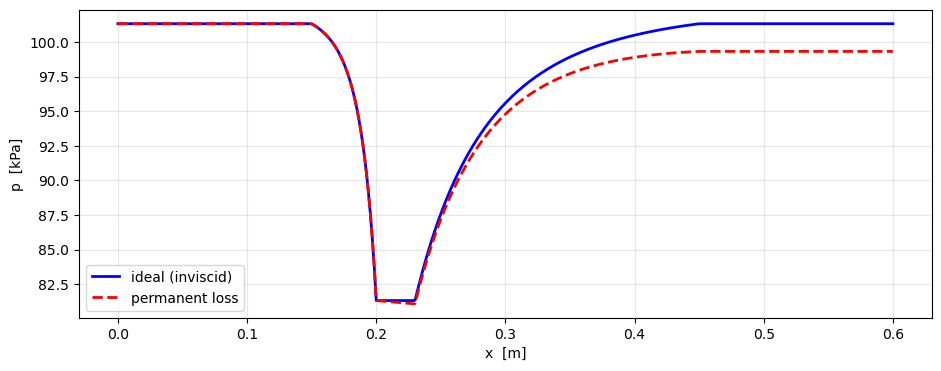

In [50]:
# Plotting
plt.figure(figsize=(11, 4))

plt.plot(x, p_x/1e3,    color="blue", lw=2, label="ideal (inviscid)")
plt.plot(x, p_real/1e3, color="red",  lw=2, ls="--", label="permanent loss")

plt.xlabel("x  [m]")
plt.ylabel("p  [kPa]")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Observation:

- The permanent loss is measurable. The inviscid equation cannot predict it at all.

## 3. Relaxing incompressibility

Let $\Gamma = c_p/c_v$ be the ratio of specific heats and $M = v/c$ the Mach number, with $c$ the speed of sound.

For a perfect gas in isentropic flow the Bernoulli integral $\int dp/\rho$ gives a stagnation pressure:

$$\frac{p_0}{p} = \left(1 + \frac{\Gamma-1}{2}\,M^2\right)^{\Gamma/(\Gamma-1)}$$

while constant density gives simply $p_0 - p = \tfrac{1}{2}\rho v^2$. The ratio of the two measures how much the constant-density assumption costs.

In [51]:
# Ratio of the compressible to the incompressible stagnation pressure rise

M = np.linspace(0.01, 1.0, 500)

# Pressure ratio

ratio = ((1.0 + 0.5*(Gamma-1)*M**2)**(Gamma/(Gamma-1)) - 1.0) / (0.5*Gamma*M**2)

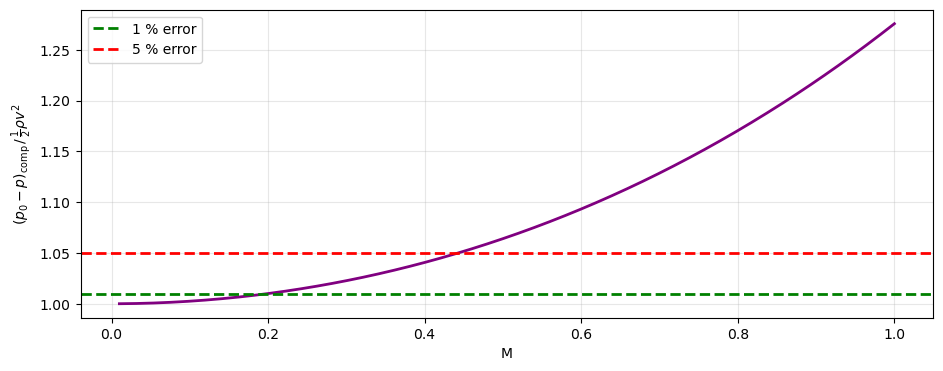

In [52]:
# Plotting
plt.figure(figsize=(11, 4))

plt.plot(M, ratio, color="purple", lw=2)

plt.axhline(1.01, color="green", ls="--", lw=2, label="1 % error")
plt.axhline(1.05, color="red",   ls="--", lw=2, label="5 % error")

plt.xlabel("M")
plt.ylabel(r"$(p_0-p)_{\rm comp}\, / \,\frac{1}{2}\rho v^2$")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [53]:
# Where do those lines cross?

M_1 = np.interp(1.01, ratio, M)  # 1% line
M_5 = np.interp(1.05, ratio, M)  # 5% line

print(f"1 % error at M = {M_1:4.2f}  ->  v = {M_1*c_a:5.1f} m/s in air")
print(f"5 % error at M = {M_5:4.2f}  ->  v = {M_5*c_a:5.1f} m/s in air")

1 % error at M = 0.20  ->  v =  68.5 m/s in air
5 % error at M = 0.44  ->  v = 151.9 m/s in air


### The same meter, now with air: what pressure drop takes the throat to M = 0.3?

In [54]:
# The same meter, now with air: what pressure drop takes the throat to M = 0.3?
v_2 = 0.30 * c_a                                       # m/s

dp_air = 0.5 * rho_a * (1.0 - beta**4) * v_2**2        # Pa

print(f"v_2    = {v_2:6.1f} m/s")
print(f"dp_air = {dp_air/1e3:6.2f} kPa")

v_2    =  102.9 m/s
dp_air =   5.96 kPa


### Observations:

- Below $M \approx 0.2$ the constant-density result is within 1%, which is why the incompressible Bernoulli equation is used for nearly all liquid and low-speed gas flows.

- At $M = 0.3$ the error is already about 2%, and it grows quickly after that.

- In air, only about 6 kPa across this meter is enough to reach that speed.

- The same 20 kPa that is perfectly safe for water puts the air throat well into the compressible regime.